### KNN

## 1. Concept and Theory of KNN

K-Nearest Neighbors (KNN) is a **supervised, non-parametric, instance-based (lazy learning)** algorithm used for:

* Classification
* Regression

### Key Idea

A data point is classified based on how its **nearest neighbors** are classified.

* No explicit training phase
* Stores entire training dataset
* Prediction happens at query time

### Example Intuition

If most nearby passengers survived, a new similar passenger is likely to survive.

## 2. Why KNN is Called a Lazy Learner

| Aspect      | Explanation                  |
| ----------- | ---------------------------- |
| Training    | No model building            |
| Storage     | Stores all data              |
| Prediction  | Heavy computation            |
| Flexibility | Adapts to complex boundaries |


## 3. Distance Functions

Distance functions determine **closeness** between data points.



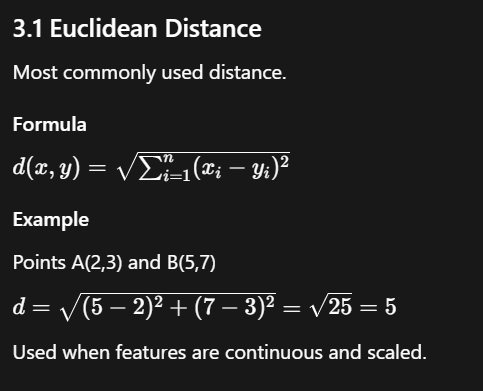

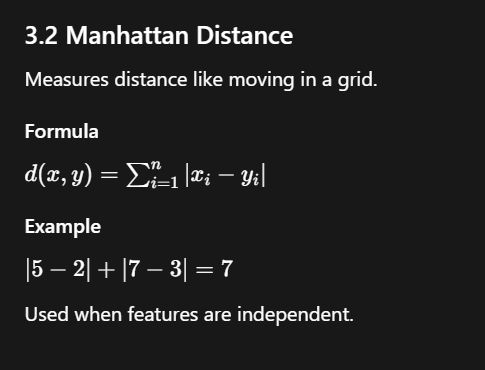

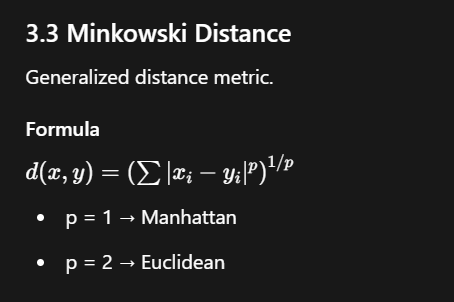

## 4. Why Use KNN?

### Advantages

* Simple to understand
* No assumptions about data
* Works well with small datasets
* Handles nonlinear decision boundaries

### Disadvantages

* Computationally expensive
* Sensitive to feature scaling
* Poor performance on large datasets

## 5. Mathematical Approach of KNN

### Step-by-Step Process

1. Choose value of **K**
2. Compute distance between test point and all training points
3. Sort distances
4. Select K nearest neighbors
5. Majority voting (classification)
6. Average value (regression)

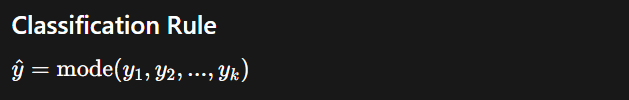

## 6. Choosing the Value of K

| K Value | Effect       |
| ------- | ------------ |
| Small K | Overfitting  |
| Large K | Underfitting |


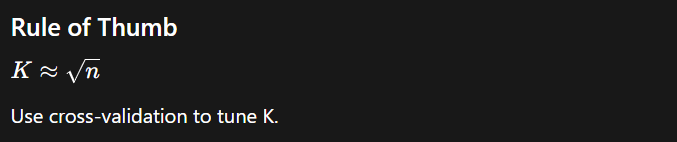

## 7. Dataset with Problem Description

### Problem Statement

Predict whether a passenger survived the Titanic disaster using KNN.

### Dataset Features

* Age
* Fare
* Pclass
* Sex
* Parch

Target:

* Survived (0/1)

## 8. Data Preprocessing (Critical for KNN)

### Why Scaling is Mandatory

KNN relies on distance → larger values dominate.

### Techniques

* StandardScaler
* MinMaxScaler

In [1]:
## 9. Practical Python Implementation

### Import Libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [6]:
### Load Dataset

df = pd.read_csv("titanic.csv")

drop_cols = [col for col in df.columns if 'zero' in col.lower()]

df.drop(columns=drop_cols, inplace=True, errors='ignore')


df.rename(columns={'2urvived': 'Survived'}, inplace=True)

### Feature Selection

X = df[['Age','Fare','Pclass','Parch']]
y = df['Survived']


### Handle Missing Values

X['Age'].fillna(X['Age'].median(), inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25276\2691762621.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(X['Age'].median(), inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25276\2691762621.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Age'].fillna(X['Age'].median(), inplace=True)


In [16]:
### Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Model Training

knn = KNeighborsClassifier(n_neighbors=31, metric='euclidean')
knn.fit(X_train_scaled, y_train)

,n_neighbors,31
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [17]:
### Predictions & Evaluation

y_pred = knn.predict(X_test_scaled)

accuracy_score(y_test, y_pred)
confusion_matrix(y_test, y_pred)

array([[186,   3],
       [ 65,   8]])

In [19]:

## 10. Hyperparameter Tuning for K

from sklearn.model_selection import GridSearchCV

params = {'n_neighbors': range(1,261)}
grid = GridSearchCV(KNeighborsClassifier(), params, cv=5)
grid.fit(X_train_scaled, y_train)

grid.best_params_

{'n_neighbors': 31}

## 11. KNN Capstone Project

### Title

Titanic Survival Prediction using KNN

### Objective

Build a distance-based classification system to predict survival.

### Steps

1. Data cleaning
2. Feature engineering
3. Scaling
4. K selection
5. Model training
6. Evaluation

### Metrics

* Accuracy
* Confusion Matrix

## 12. Business Insights

* Similar passengers had similar survival chances
* Distance-based logic mimics human reasoning
* Feature scaling is critical

## 13. When NOT to Use KNN

* Large datasets
* High dimensional data
* Real-time prediction systems

## 14. Comparison with Other Algorithms

| Algorithm           | Strength            |
| ------------------- | ------------------- |
| KNN                 | Simplicity          |
| Logistic Regression | Interpretability    |
| SVM                 | Margin maximization |
| Decision Tree       | Rule-based          |

## 15. Final Summary

* KNN is intuitive and powerful
* Distance metric selection matters
* Scaling is mandatory
* Best for small to medium datasets